In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA H100 80GB HBM3


In [6]:
DATA_ROOT = '/content/drive/MyDrive/Datasets/Plant Village-Processed/Plant Village Processed/Tomato'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'Train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [7]:
#Transforms
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [8]:
# Datasets & Loaders
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'Train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'Val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 11108 | Val: 2502
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [9]:
# ResNet-18 from Scratch
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        self.in_ch = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def _make_layer(self, out_ch, num_blocks, stride):
        layers = [BasicBlock(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


model = ResNet18().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 11.18M


In [10]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [13]:
from tqdm import tqdm
import copy, time

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total


CKPT_DIR = '/content/drive/MyDrive/Datasets/Plant Village-Processed/Plant Village Processed'

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())
patience, no_improve = 5, 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        tag = ' ★'
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_acc': best_acc,
            'history': history
        }, f'{CKPT_DIR}/checkpoint_best.pth')
    else:
        no_improve += 1
        tag = ''

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, f'{CKPT_DIR}/checkpoint_latest.pth')

    print(f'Epoch {epoch:>3}  '
          f'TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  '
          f'{elapsed:.0f}s{tag}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_wts)
print(f'\nBest val accuracy: {best_acc:.4%}')

Epoch   1  TrLoss=1.1634  TrAcc=62.74%  VaLoss=0.8388  VaAcc=79.58%  3127s ★


Epoch   2  TrLoss=0.9778  TrAcc=73.11%  VaLoss=0.8582  VaAcc=80.74%  897s ★


Epoch   3  TrLoss=0.9551  TrAcc=74.25%  VaLoss=0.7921  VaAcc=82.05%  352s ★


Epoch   4  TrLoss=0.9451  TrAcc=74.63%  VaLoss=0.8453  VaAcc=79.86%  159s


Epoch   5  TrLoss=0.9287  TrAcc=76.11%  VaLoss=0.8454  VaAcc=77.06%  91s


...

Epoch  36  TrLoss=0.4657  TrAcc=98.24%  VaLoss=0.4335  VaAcc=99.76%  39s ★


Epoch  37  TrLoss=0.4660  TrAcc=98.24%  VaLoss=0.4342  VaAcc=99.72%  41s


Epoch  38  TrLoss=0.4627  TrAcc=98.53%  VaLoss=0.4339  VaAcc=99.64%  39s


Epoch  39  TrLoss=0.4639  TrAcc=98.24%  VaLoss=0.4331  VaAcc=99.68%  41s


Epoch  40  TrLoss=0.4598  TrAcc=98.53%  VaLoss=0.4333  VaAcc=99.72%  40s

Best val accuracy: 99.7602%


In [14]:
torch.save({
    'model_state': best_wts,
    'classes': train_ds.classes,
    'best_val_acc': best_acc
}, f'{CKPT_DIR}/resnet18_best.pth')
print(f'Saved best model with val acc: {best_acc:.4%}')

Saved best model with val acc: 99.7602%


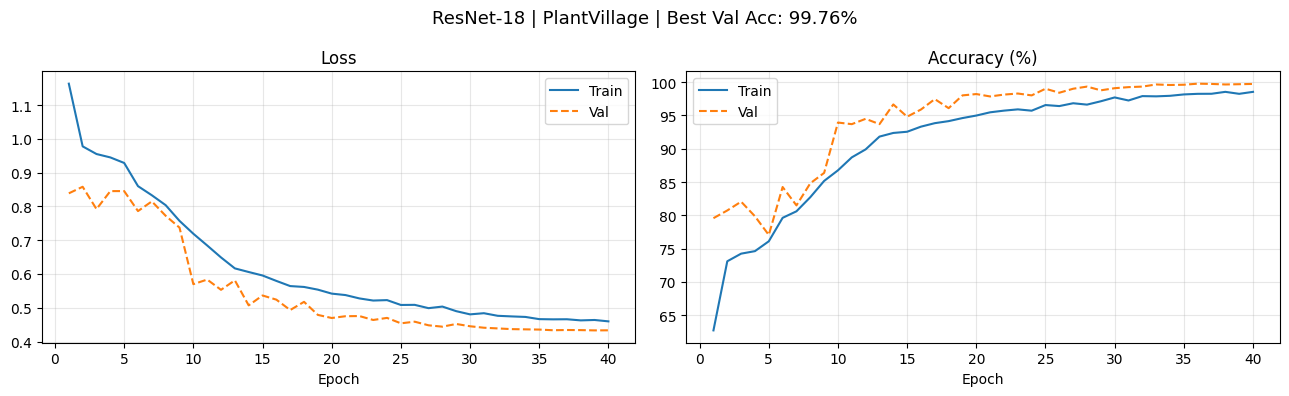

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'ResNet-18 | PlantVillage | Best Val Acc: {best_acc:.2%}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/resnet18_curves.png', dpi=150)
plt.show()

In [16]:
test_path = os.path.join(DATA_ROOT, 'Test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'Val')

eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            out = model(imgs.to(DEVICE))
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
overall    = (all_preds == all_labels).float().mean().item()
print(f'\nOverall accuracy on {os.path.basename(eval_path)}: {overall:.4%}\n')

for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')


Overall accuracy on Test: 99.6429%

  Bacterial Spot                            100.00%  (n=43)
  Early Blight                              100.00%  (n=48)
  Healthy                                   100.00%  (n=49)
  Late Blight                               100.00%  (n=47)
  Septoria Leaf Spot                        97.73%  (n=44)
  Yellow Leaf Curl Virus                    100.00%  (n=49)


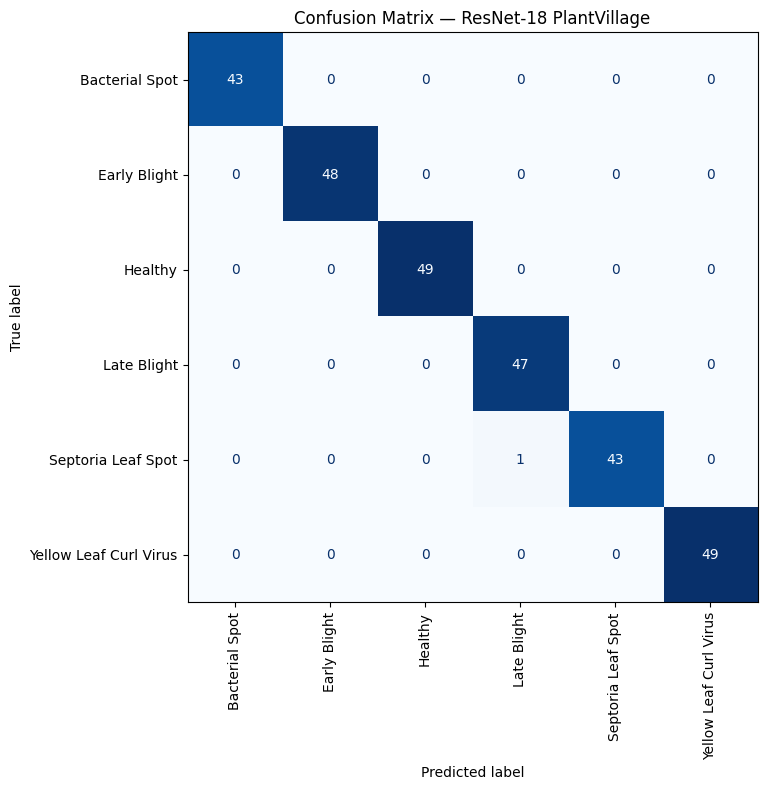

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels.numpy(), all_preds.numpy())
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES//2), max(8, NUM_CLASSES//2)))
ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes).plot(
    ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — ResNet-18 PlantVillage')
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/resnet18_cm.png', dpi=120)
plt.show()


In [18]:
from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=eval_ds.classes))

                        precision    recall  f1-score   support

        Bacterial Spot       1.00      1.00      1.00        43
          Early Blight       1.00      1.00      1.00        48
               Healthy       1.00      1.00      1.00        49
           Late Blight       0.98      1.00      0.99        47
    Septoria Leaf Spot       1.00      0.98      0.99        44
Yellow Leaf Curl Virus       1.00      1.00      1.00        49

              accuracy                           1.00       280
             macro avg       1.00      1.00      1.00       280
          weighted avg       1.00      1.00      1.00       280

